### Noisy features plot across all models and datasets

In [1]:
import os
import csv
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
output_dir = "Noisy_features_lists"
methods = ["TACENR", "GraphLIME", "GNNExplainer", "GraphSVX", "COMPINEX"]
embedding_methods = ["GCN", "GAT", "GraphSAGE"] 
datasets = ["Cora", "CiteSeer", "Pubmed", "PPI"] 
embedding_dimension = 64   

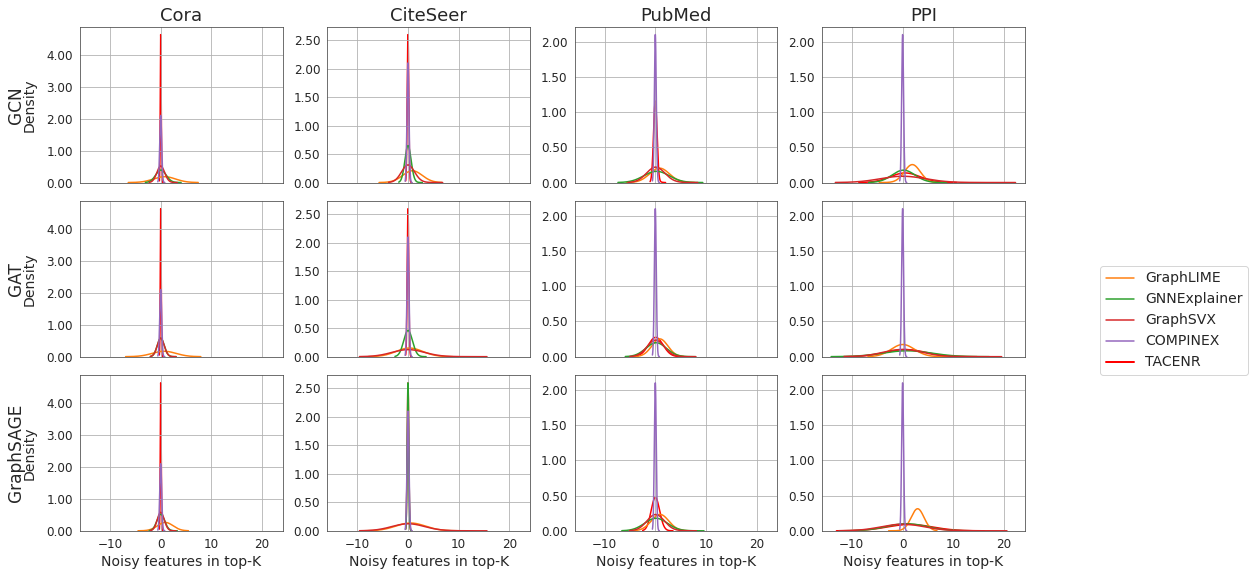

In [ ]:
from matplotlib.ticker import FormatStrFormatter   
results = {}
method_colors = {
    "TACENR": "red",       
    "GraphLIME": "C1",
    "GNNExplainer": "C2",
    "GraphSVX": "C3",
    "COMPINEX": "C4"
}
ordered_methods = [m for m in methods if m != "TACENR"] + ["TACENR"]

for emb_method in embedding_methods:
    for dataset in datasets:
        result_key = (emb_method, dataset)
        results[result_key] = {}
        for method in methods:
            filename = f"noisy_counts_{method}_{emb_method}_{embedding_dimension}_{dataset}.csv"
            filepath = os.path.join(output_dir, filename)
            if os.path.exists(filepath):
                with open(filepath, mode="r") as f:
                    reader = csv.reader(f)
                    next(reader)   
                    results[result_key][method] = [int(row[0]) for row in reader]
            else:
                print(f"Warning: File not found: {filepath}")
                results[result_key][method] = []   
 
sns.set_style("whitegrid", {
        "axes.facecolor": "#FFFFFF",      
        "grid.color": "#B0B0B0",     
    "axes.edgecolor": "#4D4D4D",    
    })
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 9), sharex=True, sharey=False)
colors = ['C0', 'C1', 'C2', 'C3','C4']

for i, emb_method in enumerate(embedding_methods):
    for j, dataset in enumerate(datasets):
        key = (emb_method, dataset)
        if key not in results or all(len(results[key].get(m, [])) == 0 for m in methods):
            print(f"Skipping: No data for {emb_method} on {dataset}")
            continue  

        ax = axes[i, j]

        for method in ordered_methods:
            k = methods.index(method)
            noisy_counts = results[key].get(method, [])
            if len(noisy_counts) == 0:
                continue 

            if np.all(np.array(noisy_counts) == 0):
                noisy_counts[0] = 0.25
            if dataset == "Cora" and method == "GraphLIME" and emb_method == "GraphSAGE":
                noisy_counts[0] = 0

            sns.kdeplot(
                noisy_counts,
                label=method if (i == 0 and j == 0) else None,
                color=method_colors.get(method, colors[k]),

                fill=False,
                linewidth=1.5,
                bw_adjust=14,
                ax=ax,
                zorder=k
            )

        if j == 0:
            ax.set_ylabel("Density", fontsize=14, labelpad=10)
            ax.annotate(emb_method, xy=(-0.27, 0.5), xycoords='axes fraction',
                        fontsize=17, ha='right', va='center', rotation=90)
        else:
            ax.set_ylabel("")
        display_name = "PubMed" if dataset.lower() == "pubmed" else dataset
        if i == 0:
            ax.set_title(display_name, fontsize=18)

        ax.tick_params(axis='both', labelsize=12)
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        if i == len(embedding_methods) - 1:
            ax.set_xlabel("Noisy features in top-K", fontsize=14)

        ax.grid(True)


handles, labels = axes[0, 0].get_legend_handles_labels()
handles, labels = [], []
for method in ordered_methods:
    handles.append(plt.Line2D([0], [0],
                              color=method_colors.get(method, "black"),
                              lw=2 if method == "TACENR" else 1.5))
    labels.append(method)

fig.legend(
    handles, labels,
    loc='center left',
    bbox_to_anchor=(0.92, 0.5),   
    fontsize=14,
    frameon=True
)
plt.tight_layout(rect=[0, 0.1, 0.9, 1])
os.makedirs("Figures", exist_ok=True)

plot_filename_base = "Figures/noisy_features_plot"

plt.savefig(f"{plot_filename_base}.pdf", bbox_inches='tight')
plt.show()
 